# Activity Cliff Recognition

Quantifies whether the representation space separates pairs of molecules that are
chemically near-identical (Tanimoto > 0.9) but exhibit large activity differences
(>10× potency fold). Activity cliffs are the failure mode where structure-only
encoders break down — chemistry-driven representations cannot distinguish molecules
that share scaffolds yet diverge in biology. A representation that places cliff
pairs *far apart* has internalised signal beyond chemical structure.

**Benchmark.** MoleculeACE (van Tilborg et al., *J. Chem. Inf. Model.* 2022,
[doi:10.1021/acs.jcim.2c01073](https://doi.org/10.1021/acs.jcim.2c01073)) —
30 ChEMBL macromolecular targets, ~35 k molecules, with pre-computed cliff-pair
annotations. Repo: <https://github.com/molML/MoleculeACE>.

**Approach.**
1. Extract graph-level embeddings from each pretrained PairMixer-12M checkpoint
2. Linear (Ridge) probe on the train split, evaluate on the test split
3. Report **cliff-RMSE** (RMSE restricted to test molecules flagged as cliffs)
   alongside the standard test RMSE
4. Embedding-space sanity check: compare embedding-distance distributions for
   cliff pairs vs Tanimoto-matched non-cliff (smooth) pairs


In [1]:
import os

# ── GPU selection ────────────────────────────────────────────────────────────
GPU_ID = 0
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})
sns.set_style("whitegrid")

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "notebooks"))

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"physical GPU {GPU_ID} -> torch sees {torch.cuda.device_count()} device(s); using {DEVICE}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")


physical GPU 0 -> torch sees 1 device(s); using cuda:0
  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## Setup: MoleculeACE benchmark

`MoleculeACE` ships per-target CSVs with pre-computed `cliff_mols_test`
annotations. Install once if missing — pulled into the active conda env so the
package's bundled CSVs land alongside the rest of graphium's deps.


In [2]:
# try:
from MoleculeACE import Data, calc_cliff_rmse
from MoleculeACE.benchmark.const import datasets as MOLACE_DATASETS
# except ImportError as exc:
#     raise ImportError(
#         "MoleculeACE is required for this notebook. Install into the active env, e.g.\n"
#         "  pip install git+https://github.com/molML/MoleculeACE.git\n"
#         "Docs: https://github.com/molML/MoleculeACE — bundled CSVs ship with the package."
#     ) from exc

print(f"MoleculeACE: {len(MOLACE_DATASETS)} benchmark targets")
print(f"  first 6: {MOLACE_DATASETS[:6]}")


2026-05-04 13:37:47.160269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 13:37:47.212822: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 13:37:48.335921: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


MoleculeACE: 30 benchmark targets
  first 6: ['CHEMBL4203_Ki', 'CHEMBL2034_Ki', 'CHEMBL233_Ki', 'CHEMBL4616_EC50', 'CHEMBL287_Ki', 'CHEMBL218_EC50']


## Checkpoints

Same registry as `scripts/cka_analysis.py` — most-recent run per pretrain dataset
case for the PairMixer-12M backbone.


In [3]:
CKPT_DIR = REPO / "models_checkpoints"
CHECKPOINTS = {
    "toymix":               CKPT_DIR / "small-dataset/pairmixer_12M/2026-05-02_01-02-56_20260502_010256/toymix_pairmixer_12M_epochepoch=099_20260502_010256.ckpt",
    "toymix_dti_esmcv2":    CKPT_DIR / "toymix-dti-esmc-v2/pairmixer_12M/2026-04-28_01-54-53_20260428_015453/last.ckpt",
    "toymix_bbbc047":       CKPT_DIR / "toymix_bbbc047/pairmixer_12M/2026-04-18_11-20-55_20260418_112055/last.ckpt",
    "toymix_lpm24_litopenai": CKPT_DIR / "toymix-lpm24-litopenai/pairmixer_12M/2026-04-24_22-23-52_20260424_222352/last.ckpt",
    "toymix_all":           CKPT_DIR / "toymix_dti_esmc_v2_lpm24_litopenai_bbbc047/pairmixer_12M/2026-05-03_01-18-55_20260503_011855/last.ckpt",
}

CKPT_MODALITY = {
    "toymix":               "uni-modal",
    "toymix_dti_esmcv2":    "multi-modal",
    "toymix_bbbc047":       "multi-modal",
    "toymix_lpm24_litopenai": "multi-modal",
    "toymix_all":           "multi-modal",
}

CKPT_COLOR = {
    "toymix":               "#4C72B0",
    "toymix_dti_esmcv2":    "#DD8452",
    "toymix_bbbc047":       "#55A868",
    "toymix_lpm24_litopenai": "#C44E52",
    "toymix_all":           "#8172B2",
}

CKPT_ORDER = list(CHECKPOINTS.keys())

for n, p in CHECKPOINTS.items():
    print(f"  {n:25s} {'OK' if p.exists() else 'MISSING':8s}  {p.relative_to(REPO)}")


  toymix                    OK        models_checkpoints/small-dataset/pairmixer_12M/2026-05-02_01-02-56_20260502_010256/toymix_pairmixer_12M_epochepoch=099_20260502_010256.ckpt
  toymix_dti_esmcv2         OK        models_checkpoints/toymix-dti-esmc-v2/pairmixer_12M/2026-04-28_01-54-53_20260428_015453/last.ckpt
  toymix_bbbc047            OK        models_checkpoints/toymix_bbbc047/pairmixer_12M/2026-04-18_11-20-55_20260418_112055/last.ckpt
  toymix_lpm24_litopenai    OK        models_checkpoints/toymix-lpm24-litopenai/pairmixer_12M/2026-04-24_22-23-52_20260424_222352/last.ckpt
  toymix_all                OK        models_checkpoints/toymix_dti_esmc_v2_lpm24_litopenai_bbbc047/pairmixer_12M/2026-05-03_01-18-55_20260503_011855/last.ckpt


## Featurization

Matches PairMixer-12M's expanded RDKit feature set (see
`expts/hydra-configs/model/pairmixer_12M.yaml`). Featurization is checkpoint-
agnostic — it depends only on the architecture — so we featurize the unique
SMILES once and reuse the graphs across all five backbones.


In [4]:
FEATURIZATION = {
    "atom_property_list_onehot": ["atomic-number", "group", "period", "total-valence", "hybridization", "chirality"],
    "atom_property_list_float":  ["degree", "formal-charge", "radical-electron", "aromatic", "in-ring", "mass", "electronegativity", "vdw-radius", "num-ring"],
    "edge_property_list":        ["bond-type-onehot", "stereo", "in-ring", "conjugated"],
    "add_self_loop": False,
    "explicit_H": False,
    "use_bonds_weights": False,
    "pos_encoding_as_features": {
        "pos_types": {
            "lap_eigvec": {"pos_level": "node", "pos_type": "laplacian_eigvec", "num_pos": 8, "normalization": "none", "disconnected_comp": True},
            "lap_eigval": {"pos_level": "node", "pos_type": "laplacian_eigval", "num_pos": 8, "normalization": "none", "disconnected_comp": True},
            "rw_pos":     {"pos_level": "node", "pos_type": "rw_return_probs", "ksteps": 16},
        }
    },
}


## 1. Load MoleculeACE benchmark data

Subset to 8 targets to keep runtime reasonable (~1500 molecules each). Append more
to `TARGETS` to extend the analysis. `Data(target)` populates `smiles_train`,
`smiles_test`, `y_train`, `y_test`, and `cliff_mols_test` — a binary array marking
which test molecules are part of cliff pairs.


In [5]:
# 8 representative targets — first 8 alphabetically. Expand TARGETS for a
# fuller sweep (each adds ~1500 molecules across train+test).
TARGETS = MOLACE_DATASETS[:8]

DATASETS = {}
for target in TARGETS:
    d = Data(target)
    DATASETS[target] = {
        "smi_tr":   list(d.smiles_train),
        "smi_te":   list(d.smiles_test),
        "y_tr":     np.asarray(d.y_train, dtype=float),
        "y_te":     np.asarray(d.y_test,  dtype=float),
        "cliff_te": np.asarray(d.cliff_mols_test).astype(int),
    }
    n_cliff = int(DATASETS[target]["cliff_te"].sum())
    print(f"  {target:30s} train={len(d.smiles_train):4d}  test={len(d.smiles_test):4d}  cliff={n_cliff}")


  CHEMBL4203_Ki                  train= 582  test= 149  cliff=13
  CHEMBL2034_Ki                  train= 598  test= 152  cliff=52
  CHEMBL233_Ki                   train=2512  test= 630  cliff=259
  CHEMBL4616_EC50                train= 543  test= 139  cliff=73
  CHEMBL287_Ki                   train=1061  test= 267  cliff=103
  CHEMBL218_EC50                 train= 823  test= 208  cliff=76
  CHEMBL264_Ki                   train=2288  test= 574  cliff=239
  CHEMBL219_Ki                   train=1491  test= 374  cliff=148


In [6]:
import hashlib
from tqdm.auto import tqdm
import datamol as dm
from graphium.features.featurizer import mol_to_pyggraph

all_smi = sorted({s for d in DATASETS.values() for s in d["smi_tr"] + d["smi_te"]})
print(f"unique SMILES across {len(TARGETS)} targets: {len(all_smi)}")

# Cache featurized graphs keyed by SMILES. Cache file is namespaced by a hash of
# FEATURIZATION so different configs don\'t clash. Failed SMILES are stored as
# None so we don\'t retry them next session.
_FEAT_CACHE_DIR = REPO / "datacache" / "cliff_featurization"
_FEAT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_feat_hash = hashlib.sha1(repr(FEATURIZATION).encode()).hexdigest()[:12]
_feat_cache_path = _FEAT_CACHE_DIR / f"feat_{_feat_hash}.pt"

if _feat_cache_path.exists():
    feat_cache = torch.load(_feat_cache_path, map_location="cpu", weights_only=False)
    print(f"  loaded {len(feat_cache)} cached entries from {_feat_cache_path.name}")
else:
    feat_cache = {}

new_smiles = [s for s in all_smi if s not in feat_cache]
fail_parse = fail_feat = skip_large = 0
if new_smiles:
    print(f"  featurizing {len(new_smiles)} new SMILES (cache hits: {len(all_smi) - len(new_smiles)})")
    for smi in tqdm(new_smiles, desc="featurize"):
        mol = dm.to_mol(smi)
        if mol is None:
            fail_parse += 1; feat_cache[smi] = None; continue
        if mol.GetNumAtoms() > 200:
            skip_large += 1; feat_cache[smi] = None; continue
        try:
            g = mol_to_pyggraph(mol, on_error="raise", **FEATURIZATION)
        except Exception:
            fail_feat += 1; feat_cache[smi] = None; continue
        feat_cache[smi] = g
    torch.save(feat_cache, _feat_cache_path)
    print(f"  saved {_feat_cache_path}")

SMI_TO_IDX = {}
graphs = []
for smi in all_smi:
    g = feat_cache.get(smi)
    if g is None:
        continue
    SMI_TO_IDX[smi] = len(graphs)
    graphs.append(g)
print(f"  featurized {len(graphs)}/{len(all_smi)}  "
      f"(new: parse-fail {fail_parse}, feat-fail {fail_feat}, >200 atoms {skip_large})")


unique SMILES across 8 targets: 12262
  loaded 12262 cached entries from feat_8d9b6b847428.pt
  featurized 12253/12262  (new: parse-fail 0, feat-fail 0, >200 atoms 0)


## 2. Extract graph embeddings per checkpoint

Embedding pipeline mirrors `scripts/cka_analysis.py` and `02b_analysis_epoch.ipynb`:
`encoder_manager → pre_nn → gnn → graph_output_nn` produces the post-pool graph
representation that's consumed by ADMET task heads downstream.


In [7]:
from torch_geometric.data import Batch
from torch_geometric.nn import global_mean_pool

from graphium.trainer.predictor import PredictorModule


@torch.no_grad()
def extract_embeddings(model, graphs, batch_size=64, device=DEVICE):
    """Forward through backbone; return graph-level embeddings (n_graphs, dim)."""
    model.eval().to(device)
    out = []
    for i in range(0, len(graphs), batch_size):
        g = Batch.from_data_list(graphs[i:i+batch_size])
        for k in g.keys():
            v = g[k]
            if isinstance(v, torch.Tensor):
                if v.dtype == torch.float16: v = v.float()
                elif v.dtype == torch.int32: v = v.long()
                g[k] = v.to(device)
        g = model.encoder_manager(g)
        if model.pre_nn is not None:
            g["feat"] = model.pre_nn(g["feat"])
        if model.pre_nn_edges is not None:
            e = g["edge_feat"]
            if torch.prod(torch.as_tensor(e.shape[:-1])) == 0:
                e = torch.zeros(list(e.shape[:-1]) + [model.pre_nn_edges.out_dim],
                                device=e.device, dtype=e.dtype)
            else:
                e = model.pre_nn_edges(e)
            g["edge_feat"] = e
        g = model.gnn(g)
        gon = model.task_heads.graph_output_nn["graph"]
        out.append(gon(g).float().cpu())
    return torch.cat(out).numpy()


def load_backbone(ckpt_path, device=DEVICE):
    return PredictorModule.load_from_checkpoint(
        str(ckpt_path), map_location=device, strict=False,
    ).model


In [8]:
EMBEDDINGS = {}
for name, path in CHECKPOINTS.items():
    if not path.exists():
        print(f"  skip {name}: missing"); continue
    print(f"  {name}: loading {path.name}")
    model = load_backbone(path)
    EMBEDDINGS[name] = extract_embeddings(model, graphs, batch_size=64)
    print(f"    -> {EMBEDDINGS[name].shape}")
    del model
    if DEVICE.startswith("cuda"):
        torch.cuda.empty_cache()


  toymix: loading toymix_pairmixer_12M_epochepoch=099_20260502_010256.ckpt
    -> (12253, 512)
  toymix_dti_esmcv2: loading last.ckpt
    -> (12253, 512)
  toymix_bbbc047: loading last.ckpt
    -> (12253, 512)
  toymix_lpm24_litopenai: loading last.ckpt
    -> (12253, 512)
  toymix_all: loading last.ckpt
    -> (12253, 512)


In [9]:
# --- Foundation-model baselines (MiniMol, MolE, KPGT) ---
# Extracted via downstream encoder adapters, cached under datacache/cliff_baselines/.
# KPGT runs CPU-only via subprocess; MiniMol/MolE use their bundled packages.
import sys as _sys
_REPO_ROOT = str(REPO)
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)

try:
    from downstream.model import load_encoder
except Exception as exc:
    print(f"  skip baselines: load_encoder import failed ({exc})")
    load_encoder = None

if load_encoder is not None:
    BASELINE_NAMES = ["minimol", "mole", "kpgt"]
    BASELINE_COLORS = {
        "minimol": "#666666",
        "mole":    "#999999",
        "kpgt":    "#333333",
    }
    BASELINE_CACHE_DIR = REPO / "datacache" / "cliff_baselines"
    BASELINE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    # Use SMILES in SMI_TO_IDX order so the resulting matrix is row-aligned
    # with the PairMixer EMBEDDINGS arrays.
    smi_for_baseline = sorted(SMI_TO_IDX.keys(), key=lambda s: SMI_TO_IDX[s])

    for _name in BASELINE_NAMES:
        _cache_path = BASELINE_CACHE_DIR / f"{_name}.pt"
        try:
            _enc = load_encoder(_name)
        except Exception as exc:
            print(f"  skip {_name}: load_encoder failed ({type(exc).__name__}: {exc})")
            continue
        try:
            _emb_kept, _mask = _enc.extract_cached(smi_for_baseline, cache_path=_cache_path)
        except Exception as exc:
            print(f"  skip {_name}: extract failed ({type(exc).__name__}: {exc})")
            continue
        # Inflate to (len(SMI_TO_IDX), D) aligned with SMI_TO_IDX; NaN where extraction failed.
        _D = _emb_kept.shape[1] if len(_emb_kept) else _enc.out_dim
        _full = np.full((len(SMI_TO_IDX), _D), np.nan, dtype=np.float32)
        _j = 0
        for _i, _ok in enumerate(_mask):
            if _ok:
                _full[_i] = _emb_kept[_j]
                _j += 1
        EMBEDDINGS[_name] = _full
        CKPT_MODALITY[_name] = "baseline"
        CKPT_COLOR[_name] = BASELINE_COLORS[_name]
        if _name not in CKPT_ORDER:
            CKPT_ORDER.append(_name)
        _n_fail = int((~np.asarray(_mask)).sum())
        print(f"  {_name}: {_emb_kept.shape}  (failed: {_n_fail})")

print(f"\nFinal display order: {CKPT_ORDER}")


  minimol: (12253, 512)  (failed: 0)
  mole: (12253, 1000)  (failed: 0)
  kpgt: (12253, 2304)  (failed: 0)

Final display order: ['toymix', 'toymix_dti_esmcv2', 'toymix_bbbc047', 'toymix_lpm24_litopenai', 'toymix_all', 'minimol', 'mole', 'kpgt']


## 3. Linear probe → cliff-RMSE

Ridge regression on standardised graph embeddings. Per `(checkpoint, target)`
we report two numbers:

| metric | meaning |
|---|---|
| `rmse` | standard test-set RMSE |
| `cliff_rmse` | RMSE restricted to test molecules flagged as cliffs |

Lower cliff-RMSE = the encoder distinguishes near-identical chemistry with
diverging activity. The gap `cliff_rmse − rmse` quantifies cliff vulnerability.


In [10]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


def slice_emb(target, emb_mat):
    """Return train/test embedding slices + activity labels + cliff mask.

    Baseline encoders (KPGT etc.) may fail on a few SMILES; those rows are
    filled with NaN by the loader. Skip them here so Ridge sees only valid rows.
    """
    d = DATASETS[target]
    def _ok(_smi):
        if _smi not in SMI_TO_IDX:
            return False
        return not np.isnan(emb_mat[SMI_TO_IDX[_smi]]).any()
    tr_idx = [SMI_TO_IDX[s] for s in d["smi_tr"] if _ok(s)]
    te_idx = [SMI_TO_IDX[s] for s in d["smi_te"] if _ok(s)]
    tr_y = np.asarray([y for s, y in zip(d["smi_tr"], d["y_tr"]) if _ok(s)])
    te_y = np.asarray([y for s, y in zip(d["smi_te"], d["y_te"]) if _ok(s)])
    cliff = np.asarray([c for s, c in zip(d["smi_te"], d["cliff_te"]) if _ok(s)])
    return emb_mat[tr_idx], tr_y, emb_mat[te_idx], te_y, cliff


def probe_one(emb_mat, target, alpha=1.0):
    X_tr, y_tr, X_te, y_te, cliff = slice_emb(target, emb_mat)
    if len(X_tr) == 0 or len(X_te) == 0:
        return np.nan, np.nan, 0
    sc = StandardScaler().fit(X_tr)
    X_tr = sc.transform(X_tr); X_te = sc.transform(X_te)
    reg = Ridge(alpha=alpha).fit(X_tr, y_tr)
    y_hat = reg.predict(X_te)
    rmse = float(np.sqrt(((y_hat - y_te) ** 2).mean()))
    cliff_rmse = (np.nan if cliff.sum() == 0 else
                  float(calc_cliff_rmse(y_test_pred=y_hat, y_test=y_te,
                                        cliff_mols_test=cliff.tolist())))
    return rmse, cliff_rmse, int(cliff.sum())


rows = []
for ckpt, emb in EMBEDDINGS.items():
    for target in TARGETS:
        rmse, cliff_rmse, n_cliff = probe_one(emb, target)
        rows.append({
            "checkpoint": ckpt,
            "modality":   CKPT_MODALITY[ckpt],
            "target":     target,
            "rmse":       rmse,
            "cliff_rmse": cliff_rmse,
            "n_cliff":    n_cliff,
        })
res = pd.DataFrame(rows)
print(f"collected {len(res)} (ckpt × target) probes")
res.head()


/home/shpark/.conda/envs/graphium/lib/python3.9/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.79387e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


collected 64 (ckpt × target) probes


,checkpoint,modality,target,rmse,cliff_rmse,n_cliff
0,toymix,uni-modal,CHEMBL4203_Ki,0.989817,1.277577,13
1,toymix,uni-modal,CHEMBL2034_Ki,0.769958,0.910324,52
2,toymix,uni-modal,CHEMBL233_Ki,0.989561,1.058600,259
3,toymix,uni-modal,CHEMBL4616_EC50,0.757746,0.797103,73
4,toymix,uni-modal,CHEMBL287_Ki,0.783431,0.819471,103


## 4. Cliff-RMSE heatmap (target × checkpoint)

Lower is better. The contrast between the left (standard RMSE) and right
(cliff-RMSE) panels exposes how much each pretrain regime degrades on
chemically near-identical pairs.


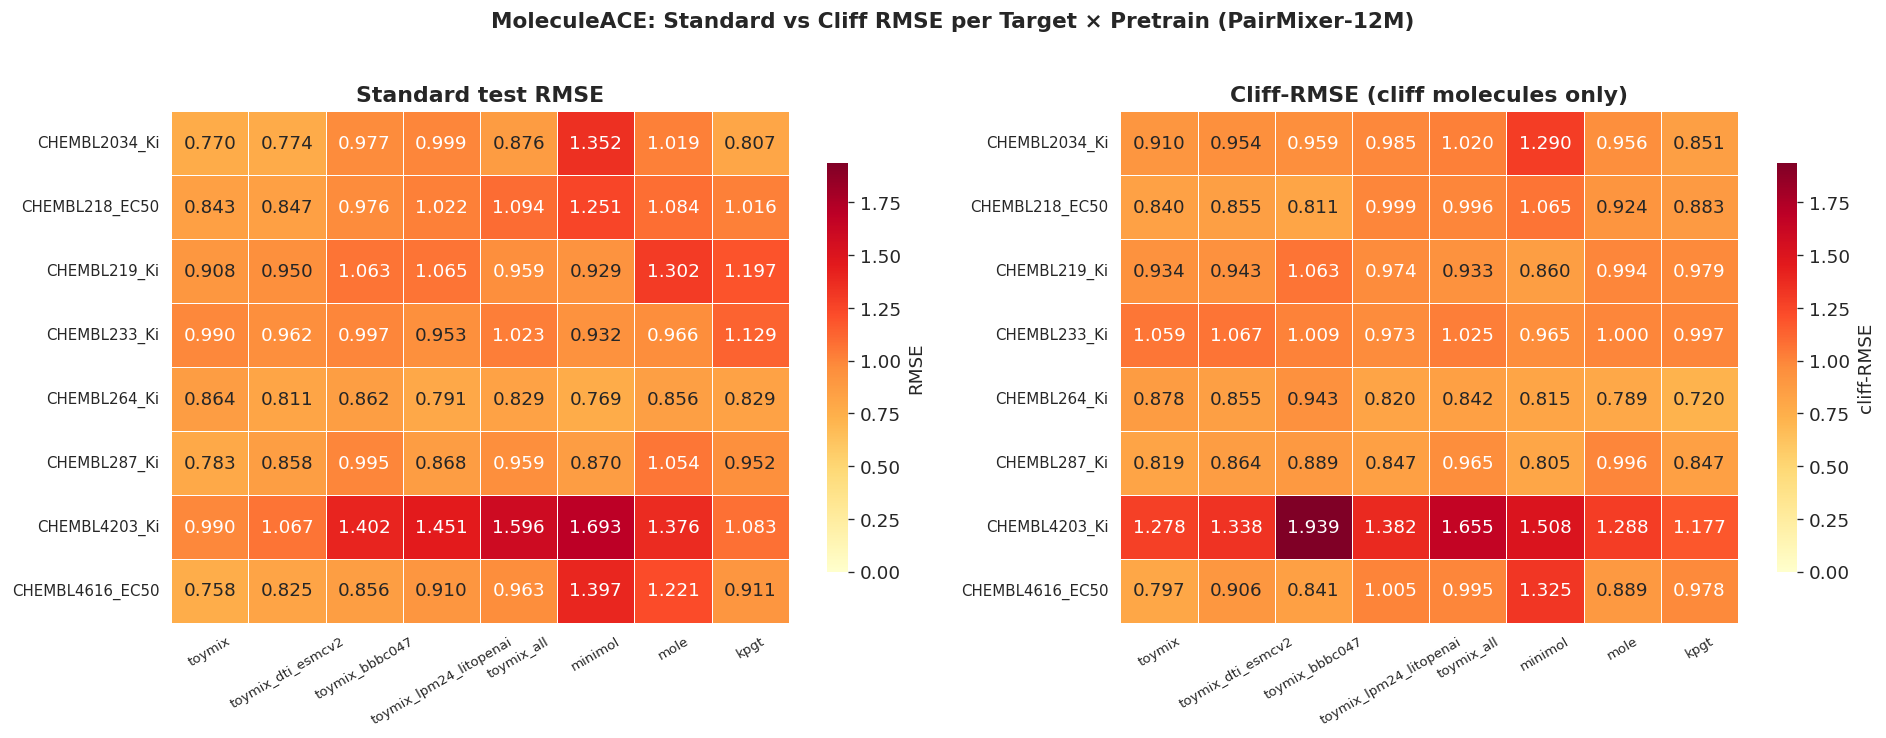

In [11]:
pivot_rmse  = res.pivot(index="target", columns="checkpoint", values="rmse")[CKPT_ORDER]
pivot_cliff = res.pivot(index="target", columns="checkpoint", values="cliff_rmse")[CKPT_ORDER]

vmax = max(pivot_rmse.max().max(), pivot_cliff.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_rmse, ax=axes[0], annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=vmax, linewidths=0.5,
            cbar_kws={"label": "RMSE", "shrink": 0.8})
axes[0].set_title("Standard test RMSE", fontweight="bold")
sns.heatmap(pivot_cliff, ax=axes[1], annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=vmax, linewidths=0.5,
            cbar_kws={"label": "cliff-RMSE", "shrink": 0.8})
axes[1].set_title("Cliff-RMSE (cliff molecules only)", fontweight="bold")
for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8, rotation=30)
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("MoleculeACE: Standard vs Cliff RMSE per Target × Pretrain (PairMixer-12M)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()

OUT_DIR = REPO / "results/cliff_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_DIR / "cliff_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Aggregate: mean RMSE per checkpoint

Averaged across the selected MoleculeACE targets. The red bars (cliff-RMSE)
should ideally sit close to the grey bars (standard RMSE) — a large gap means
the encoder fails on cliff pairs.


,checkpoint,modality,mean_rmse,std_rmse,mean_cliff,std_cliff
0,toymix,uni-modal,0.8632,0.0930,0.9394,0.1594
1,toymix_dti_esmcv2,multi-modal,0.8867,0.0976,0.9727,0.1637
2,toymix_bbbc047,multi-modal,1.0161,0.1708,1.0568,0.3661
3,toymix_lpm24_litopenai,multi-modal,1.0073,0.1995,0.9982,0.1702
4,toymix_all,multi-modal,1.0375,0.2399,1.0540,0.2500
5,minimol,baseline,1.1493,0.3223,1.0792,0.2657
6,mole,baseline,1.1097,0.1761,0.9794,0.1436
7,kpgt,baseline,0.9904,0.1407,0.9291,0.1361


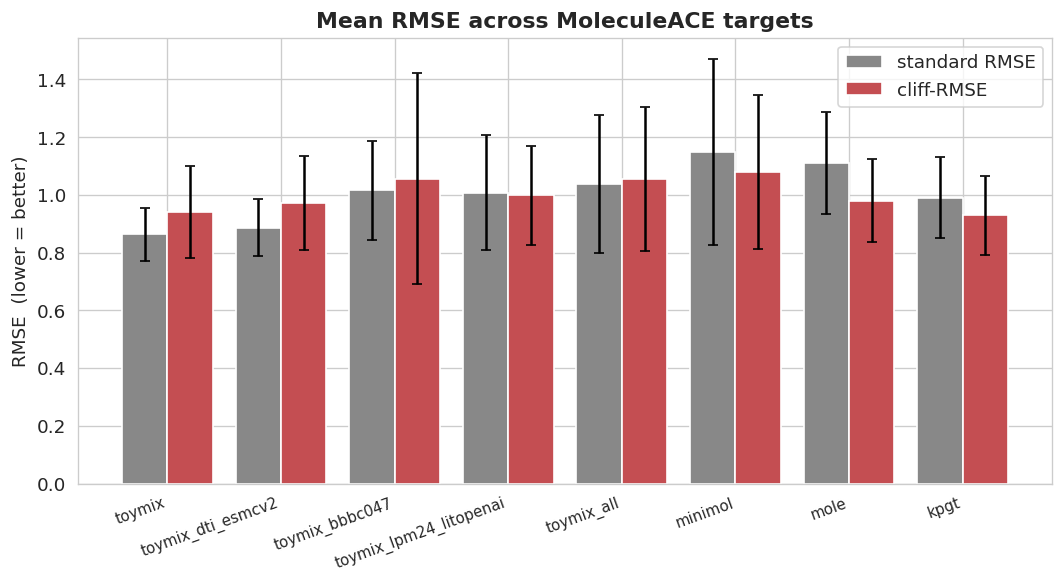

In [12]:
agg = res.groupby(["checkpoint", "modality"], as_index=False).agg(
    mean_rmse=("rmse", "mean"),
    std_rmse=("rmse", "std"),
    mean_cliff=("cliff_rmse", "mean"),
    std_cliff=("cliff_rmse", "std"),
)
agg = agg.set_index("checkpoint").reindex(CKPT_ORDER).reset_index()
display(agg.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(agg))
ax.bar(x - 0.2, agg["mean_rmse"], 0.4, yerr=agg["std_rmse"],
       label="standard RMSE", color="#888888", edgecolor="white", capsize=3)
ax.bar(x + 0.2, agg["mean_cliff"], 0.4, yerr=agg["std_cliff"],
       label="cliff-RMSE",   color="#C44E52", edgecolor="white", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(agg["checkpoint"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("RMSE  (lower = better)")
ax.set_title("Mean RMSE across MoleculeACE targets", fontweight="bold")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / "cliff_mean_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Cliff-RMSE vs Standard-RMSE

Each point is one MoleculeACE target. If the encoder cleanly separates cliff
pairs, points sit on the diagonal (cliff-RMSE ≈ RMSE). Points above the
diagonal indicate cliff vulnerability — the model fits the bulk of the data
but stumbles on chemically near-identical pairs with diverging activity.


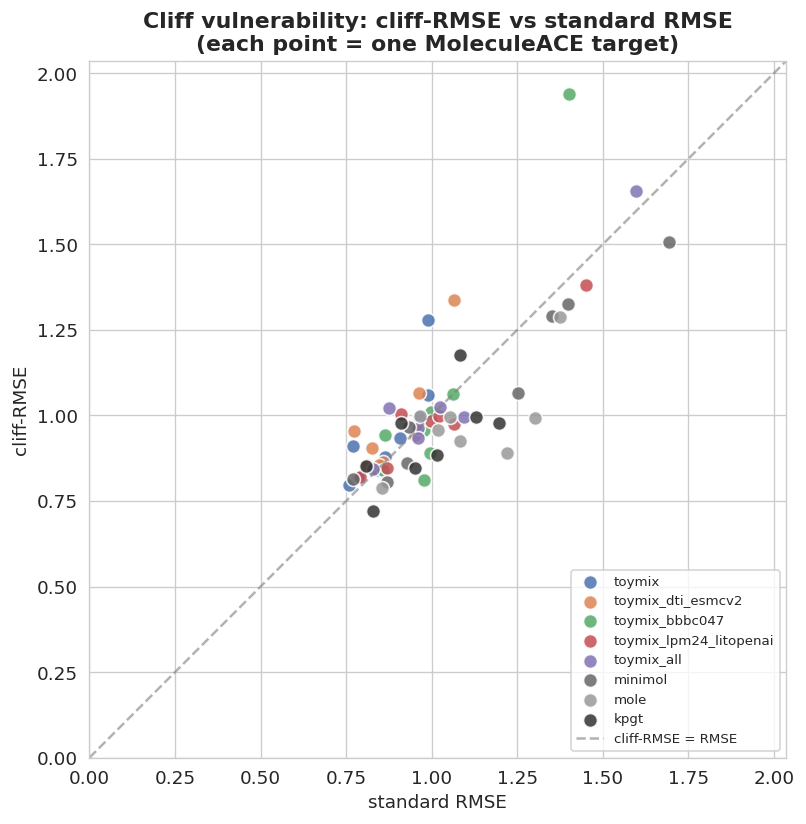

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
for ckpt in CKPT_ORDER:
    if ckpt not in EMBEDDINGS: continue
    sub = res[res["checkpoint"] == ckpt]
    ax.scatter(sub["rmse"], sub["cliff_rmse"], s=70, alpha=0.85,
               color=CKPT_COLOR[ckpt], edgecolor="white", label=ckpt)

lims = [0, max(res["rmse"].max(), res["cliff_rmse"].max()) * 1.05]
ax.plot(lims, lims, "--", color="gray", alpha=0.6, label="cliff-RMSE = RMSE")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("standard RMSE")
ax.set_ylabel("cliff-RMSE")
ax.set_title("Cliff vulnerability: cliff-RMSE vs standard RMSE\n(each point = one MoleculeACE target)",
             fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "cliff_vs_rmse.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Multi-modal gain over uni-modal `toymix`

Δ(cliff-RMSE) of each multi-modal pretrain vs the uni-modal `toymix` baseline,
target by target. Negative bars = improvement.


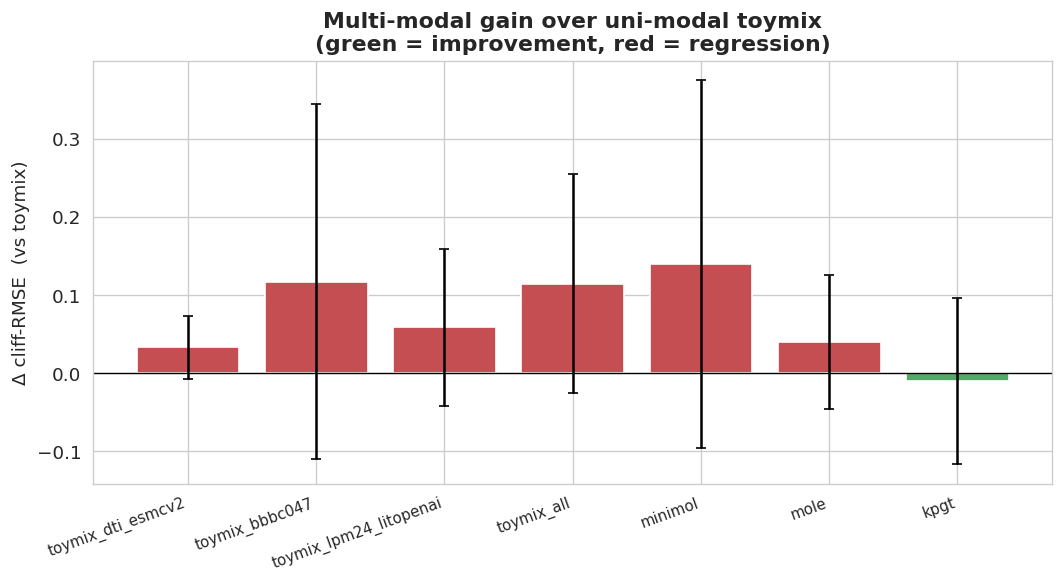

In [14]:
BASE = "toymix"
gain_rows = []
for ckpt in CKPT_ORDER:
    if ckpt == BASE or ckpt not in EMBEDDINGS: continue
    for target in TARGETS:
        try:
            base_v = res.query("checkpoint == @BASE & target == @target")["cliff_rmse"].iloc[0]
            ckpt_v = res.query("checkpoint == @ckpt & target == @target")["cliff_rmse"].iloc[0]
        except IndexError:
            continue
        gain_rows.append({"checkpoint": ckpt, "target": target,
                          "delta_cliff": ckpt_v - base_v})
gain = pd.DataFrame(gain_rows)

fig, ax = plt.subplots(figsize=(9, 5))
mean_gain = gain.groupby("checkpoint")["delta_cliff"].mean().reindex(
    [c for c in CKPT_ORDER if c != BASE and c in EMBEDDINGS])
std_gain = gain.groupby("checkpoint")["delta_cliff"].std().reindex(mean_gain.index)
colors = ["#55A868" if v < 0 else "#C44E52" for v in mean_gain]

ax.bar(mean_gain.index, mean_gain.values, yerr=std_gain.values,
       color=colors, edgecolor="white", capsize=3)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel(f"Δ cliff-RMSE  (vs {BASE})")
ax.set_title(f"Multi-modal gain over uni-modal {BASE}\n(green = improvement, red = regression)",
             fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "cliff_multimodal_gain.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Embedding-space cliff separation

Drops the linear probe entirely. For each target's *test* set we identify two
classes of pairs:

| class | criterion |
|---|---|
| **cliff** | Tanimoto > 0.9 AND \|Δactivity\| > 1.0 log unit (10× potency) |
| **smooth** | Tanimoto > 0.9 AND \|Δactivity\| ≤ 1.0 log unit |

A good representation should place cliff pairs *farther apart in embedding
space* than smooth pairs of the same chemical similarity. The cliff/smooth
mean-distance ratio (annotated above each panel) summarises the separation
— values > 1 mean cliffs are pushed apart relative to chemistry-only
expectation.


In [15]:
from rdkit import DataStructs
from rdkit.Chem import AllChem


def morgan_fp(smi, radius=2, n_bits=2048):
    mol = dm.to_mol(smi)
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits) if mol else None


def find_pairs(smi_list, y_arr, sim_thresh=0.9, act_thresh=1.0, max_pairs=20000):
    """Return (cliff_pairs, smooth_pairs) — both lists of (i, j) index tuples."""
    fps = [morgan_fp(s) for s in smi_list]
    valid = [i for i, f in enumerate(fps) if f is not None]
    cliff, smooth = [], []
    for vi, i in enumerate(valid):
        rest = valid[vi + 1:]
        if not rest: continue
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], [fps[j] for j in rest])
        for sim, j in zip(sims, rest):
            if sim < sim_thresh: continue
            d_act = abs(y_arr[i] - y_arr[j])
            (cliff if d_act > act_thresh else smooth).append((i, j))
            if len(cliff) + len(smooth) >= max_pairs:
                return cliff, smooth
    return cliff, smooth


def emb_dist(emb_mat, smi_list, pairs):
    out = []
    for i, j in pairs:
        si, sj = smi_list[i], smi_list[j]
        if si in SMI_TO_IDX and sj in SMI_TO_IDX:
            ei, ej = emb_mat[SMI_TO_IDX[si]], emb_mat[SMI_TO_IDX[sj]]
            if np.isnan(ei).any() or np.isnan(ej).any():
                continue  # baseline encoder failed on this molecule
            out.append(float(np.linalg.norm(ei - ej)))
    return np.asarray(out)


PAIRS = {}
for t in tqdm(TARGETS, desc="finding pairs (Tanimoto > 0.9)"):
    PAIRS[t] = find_pairs(DATASETS[t]["smi_te"], DATASETS[t]["y_te"])
print({t: (len(c), len(s)) for t, (c, s) in PAIRS.items()})


finding pairs (Tanimoto > 0.9):   0%|          | 0/8 [00:00<?, ?it/s]

{'CHEMBL4203_Ki': (0, 0), 'CHEMBL2034_Ki': (0, 1), 'CHEMBL233_Ki': (1, 19), 'CHEMBL4616_EC50': (0, 1), 'CHEMBL287_Ki': (1, 8), 'CHEMBL218_EC50': (1, 2), 'CHEMBL264_Ki': (4, 13), 'CHEMBL219_Ki': (1, 11)}


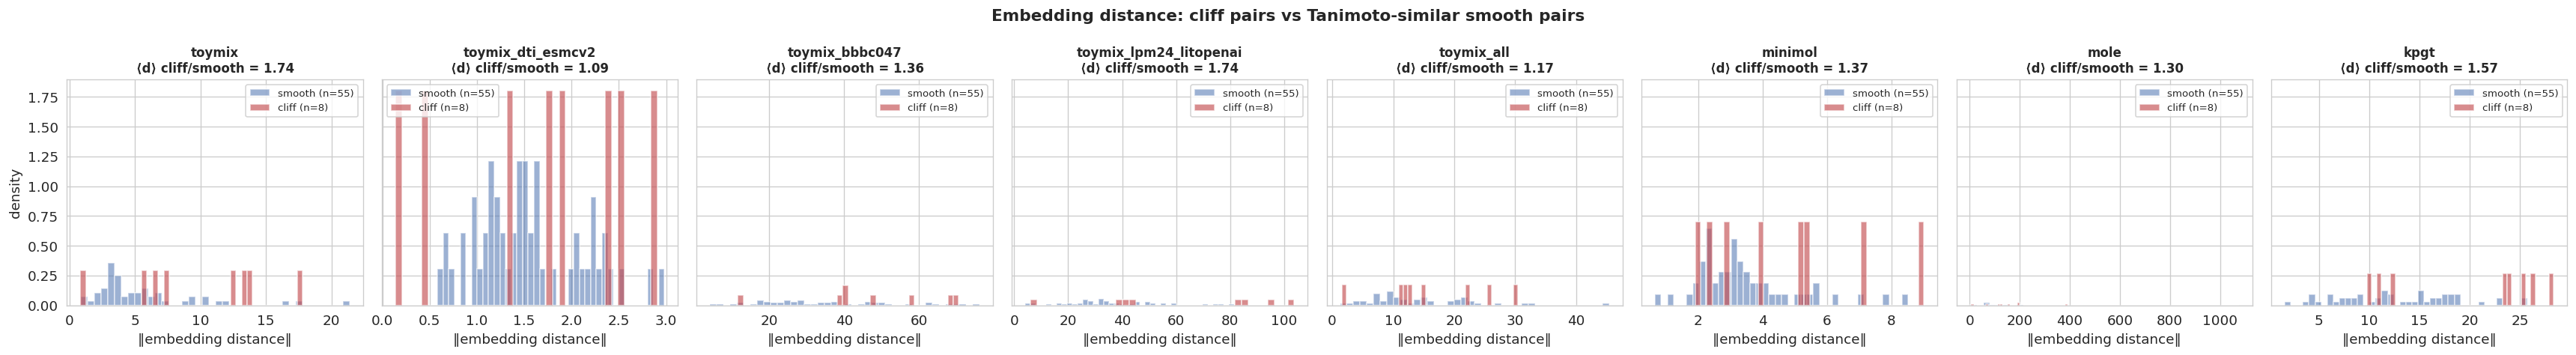


cliff/smooth mean-distance ratio (>1 = cliffs pushed apart):
  toymix                     1.739
  toymix_dti_esmcv2          1.090
  toymix_bbbc047             1.360
  toymix_lpm24_litopenai     1.738
  toymix_all                 1.172
  minimol                    1.366
  mole                       1.296
  kpgt                       1.567


In [16]:
n_cols = max(1, len(EMBEDDINGS))
fig, axes = plt.subplots(1, n_cols, figsize=(3.6 * n_cols, 4), sharey=True)
if n_cols == 1: axes = [axes]

ratios = {}
for ax, (ckpt, emb) in zip(axes, EMBEDDINGS.items()):
    cliff_d, smooth_d = [], []
    for t, (c_pairs, s_pairs) in PAIRS.items():
        smi_list = DATASETS[t]["smi_te"]
        cliff_d.append(emb_dist(emb, smi_list, c_pairs))
        smooth_d.append(emb_dist(emb, smi_list, s_pairs))
    cliff_d = np.concatenate(cliff_d) if cliff_d else np.array([])
    smooth_d = np.concatenate(smooth_d) if smooth_d else np.array([])

    if len(smooth_d):
        ax.hist(smooth_d, bins=40, alpha=0.55, color="#4C72B0",
                label=f"smooth (n={len(smooth_d)})", density=True)
    if len(cliff_d):
        ax.hist(cliff_d, bins=40, alpha=0.65, color="#C44E52",
                label=f"cliff (n={len(cliff_d)})", density=True)
    if len(cliff_d) and len(smooth_d):
        ratio = cliff_d.mean() / smooth_d.mean()
        ratios[ckpt] = ratio
        ax.set_title(f"{ckpt}\n⟨d⟩ cliff/smooth = {ratio:.2f}",
                     fontweight="bold", fontsize=10)
    else:
        ratios[ckpt] = np.nan
        ax.set_title(ckpt, fontweight="bold", fontsize=10)
    ax.set_xlabel("‖embedding distance‖")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
fig.suptitle("Embedding distance: cliff pairs vs Tanimoto-similar smooth pairs",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "cliff_emb_separation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\ncliff/smooth mean-distance ratio (>1 = cliffs pushed apart):")
for c, r in ratios.items():
    print(f"  {c:25s}  {r:.3f}" if not np.isnan(r) else f"  {c:25s}  n/a")


## 9. Summary

One row per checkpoint: mean RMSE / cliff-RMSE across the selected MoleculeACE
targets, the cliff vulnerability gap, and the embedding-space cliff/smooth
distance ratio. Persisted to `results/cliff_analysis/`.


In [17]:
summary = res.groupby("checkpoint", as_index=False).agg(
    rmse=("rmse", "mean"),
    cliff_rmse=("cliff_rmse", "mean"),
)
summary["cliff_gap"] = summary["cliff_rmse"] - summary["rmse"]
summary["cliff_smooth_d_ratio"] = summary["checkpoint"].map(ratios)
summary["modality"] = summary["checkpoint"].map(CKPT_MODALITY)
summary = summary.set_index("checkpoint").reindex(CKPT_ORDER).reset_index()
summary = summary[["checkpoint", "modality", "rmse", "cliff_rmse",
                   "cliff_gap", "cliff_smooth_d_ratio"]]
display(summary.round(4))

res.to_csv(OUT_DIR / "cliff_per_target.csv", index=False)
summary.to_csv(OUT_DIR / "cliff_summary.csv", index=False)
print(f"\nartifacts → {OUT_DIR}")


,checkpoint,modality,rmse,cliff_rmse,cliff_gap,cliff_smooth_d_ratio
0,toymix,uni-modal,0.8632,0.9394,0.0762,1.7394
1,toymix_dti_esmcv2,multi-modal,0.8867,0.9727,0.0860,1.0896
2,toymix_bbbc047,multi-modal,1.0161,1.0568,0.0407,1.3597
3,toymix_lpm24_litopenai,multi-modal,1.0073,0.9982,-0.0091,1.7383
4,toymix_all,multi-modal,1.0375,1.0540,0.0165,1.1724
5,minimol,baseline,1.1493,1.0792,-0.0701,1.3656
6,mole,baseline,1.1097,0.9794,-0.1303,1.2960
7,kpgt,baseline,0.9904,0.9291,-0.0613,1.5673



artifacts → /home/shpark/prj-molrepr/graphium/results/cliff_analysis
